# 🌾 AgriSense AI — Model Training & Evaluation Notebook
**1M1B × IBM SkillsBuild AI for Sustainability Internship**

**Author:** Nishant Sharma | Arya College of Engineering, Jaipur

**SDG Alignment:** SDG 2 (Zero Hunger) + SDG 15 (Life on Land)

---
### Notebook Structure
1. Import Libraries
2. Load & Explore Dataset (EDA)
3. Data Preprocessing
4. Model Training (Random Forest)
5. Model Evaluation (Accuracy, Classification Report, Confusion Matrix)
6. Feature Importance
7. Save Model
8. Test Predictions

## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')
print(f'pandas: {pd.__version__} | numpy: {np.__version__}')

✅ All libraries imported successfully!
pandas: 2.2.3 | numpy: 2.2.3


## 2. 📊 Load & Explore Dataset (EDA)

In [2]:
# Load the full dataset
df = pd.read_csv('C:\\Users\\star\\OneDrive\\Desktop\\agriproject\\data\\crop_disease_dataset.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dataset Shape: (1200, 14)
Columns: ['record_id', 'district', 'crop', 'season', 'growth_stage', 'crop_age_days', 'temperature_C', 'humidity_pct', 'rainfall_mm', 'soil_moisture_pct', 'wind_speed_kmh', 'prev_disease_history', 'likely_disease', 'risk_level']


,record_id,district,crop,season,growth_stage,crop_age_days,temperature_C,humidity_pct,rainfall_mm,soil_moisture_pct,wind_speed_kmh,prev_disease_history,likely_disease,risk_level
0,AGR0001,Bharatpur,Mustard,Rabi,Maturity,96,16.0,46.4,2.7,14.3,12.3,0,NaN,Low
1,AGR0002,Banswara,Maize,Kharif,Vegetative,34,36.6,95.1,30.2,63.8,24.2,0,Common Rust,Medium
2,AGR0003,Jaisalmer,Bajra,Kharif,Maturity,85,38.4,58.3,24.3,36.8,3.3,1,NaN,Low
3,AGR0004,Jodhpur,Bajra,Kharif,Flowering,47,35.6,95.6,6.9,41.3,20.5,0,Ergot,Medium
4,AGR0005,Bikaner,Wheat,Rabi,Flowering,69,25.1,62.1,9.8,25.4,9.9,0,NaN,Low
5,AGR0006,Sriganganagar,Wheat,Rabi,Vegetative,25,9.2,42.0,0.4,10.0,16.3,1,NaN,Low
6,AGR0007,Hanumangarh,Wheat,Rabi,Flowering,72,10.9,78.0,13.1,34.7,19.6,1,Powdery Mildew,Medium
7,AGR0008,Nagaur,Chickpea,Rabi,Flowering,60,19.1,60.8,23.6,55.6,2.3,0,Wilt,Medium
8,AGR0009,Jaisalmer,Bajra,Kharif,Seedling,15,27.1,87.4,4.9,28.8,2.1,0,Ergot,Medium
9,AGR0010,Nagaur,Bajra,Kharif,Flowering,57,29.2,54.4,29.3,56.2,6.3,0,NaN,Low


In [3]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   record_id             1200 non-null   object 
 1   district              1200 non-null   object 
 2   crop                  1200 non-null   object 
 3   season                1200 non-null   object 
 4   growth_stage          1200 non-null   object 
 5   crop_age_days         1200 non-null   int64  
 6   temperature_C         1200 non-null   float64
 7   humidity_pct          1200 non-null   float64
 8   rainfall_mm           1200 non-null   float64
 9   soil_moisture_pct     1200 non-null   float64
 10  wind_speed_kmh        1200 non-null   float64
 11  prev_disease_history  1200 non-null   int64  
 12  likely_disease        596 non-null    object 
 13  risk_level            1200 non-null   object 
dtypes: float64(5), int64(2), object(7)
memory usage: 13

,crop_age_days,temperature_C,humidity_pct,rainfall_mm,soil_moisture_pct,wind_speed_kmh,prev_disease_history
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,51.13,25.02,62.95,16.69,39.05,13.87,0.33
std,28.51,8.84,17.05,11.91,17.02,8.12,0.47
min,0.00,8.00,30.10,0.00,10.00,0.00,0.00
25%,28.00,17.70,50.60,7.00,26.58,6.90,0.00
50%,51.00,25.95,63.40,15.10,36.25,13.80,0.00
75%,72.00,32.00,76.43,22.60,47.95,20.70,1.00
max,120.00,42.00,98.00,49.80,93.40,27.90,1.00


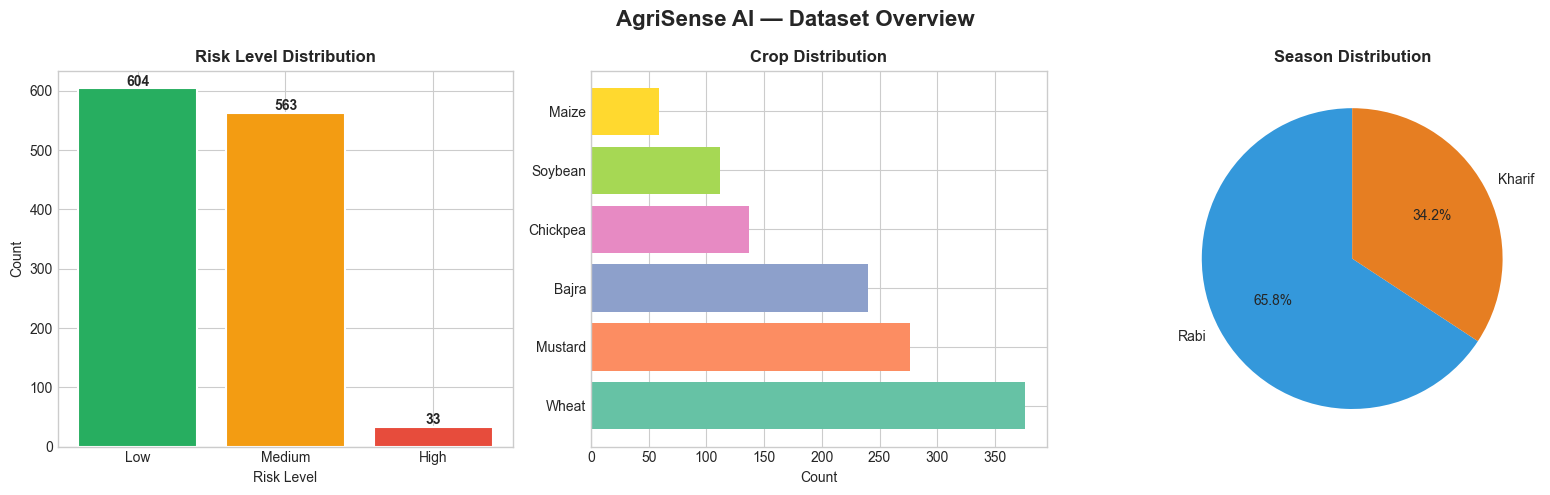

✅ Saved: screenshots/01_dataset_overview.png


In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('AgriSense AI — Dataset Overview', fontsize=16, fontweight='bold')

# Risk distribution
colors = {'Low': '#27ae60', 'Medium': '#f39c12', 'High': '#e74c3c'}
risk_counts = df['risk_level'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values,
            color=[colors[r] for r in risk_counts.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Risk Level Distribution', fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Crop distribution
crop_counts = df['crop'].value_counts()
axes[1].barh(crop_counts.index, crop_counts.values, color=sns.color_palette('Set2', len(crop_counts)))
axes[1].set_title('Crop Distribution', fontweight='bold')
axes[1].set_xlabel('Count')

# Season distribution
season_counts = df['season'].value_counts()
axes[2].pie(season_counts.values, labels=season_counts.index,
            autopct='%1.1f%%', colors=['#3498db', '#e67e22'], startangle=90)
axes[2].set_title('Season Distribution', fontweight='bold')

plt.tight_layout()
os.makedirs('../screenshots', exist_ok=True)
plt.savefig('../screenshots/01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: screenshots/01_dataset_overview.png')

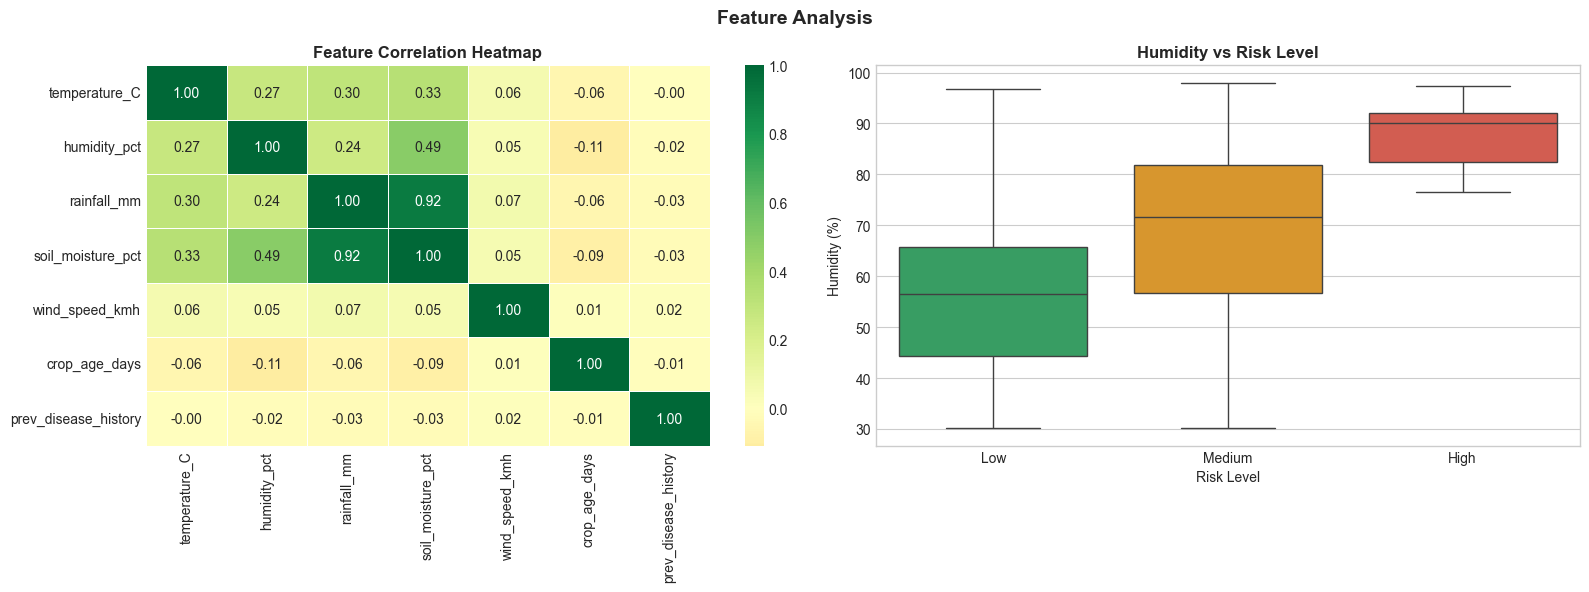

✅ Saved: screenshots/02_feature_analysis.png


In [5]:
# Correlation heatmap of numerical features
num_cols = ['temperature_C','humidity_pct','rainfall_mm',
            'soil_moisture_pct','wind_speed_kmh','crop_age_days','prev_disease_history']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis', fontsize=14, fontweight='bold')

# Heatmap
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontweight='bold')

# Humidity vs Risk boxplot
risk_order = ['Low', 'Medium', 'High']
df_plot = df.copy()
df_plot['risk_level'] = pd.Categorical(df_plot['risk_level'], categories=risk_order, ordered=True)
sns.boxplot(data=df_plot, x='risk_level', y='humidity_pct',
            palette={'Low':'#27ae60','Medium':'#f39c12','High':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Humidity vs Risk Level', fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Humidity (%)')

plt.tight_layout()
plt.savefig('../screenshots/02_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: screenshots/02_feature_analysis.png')

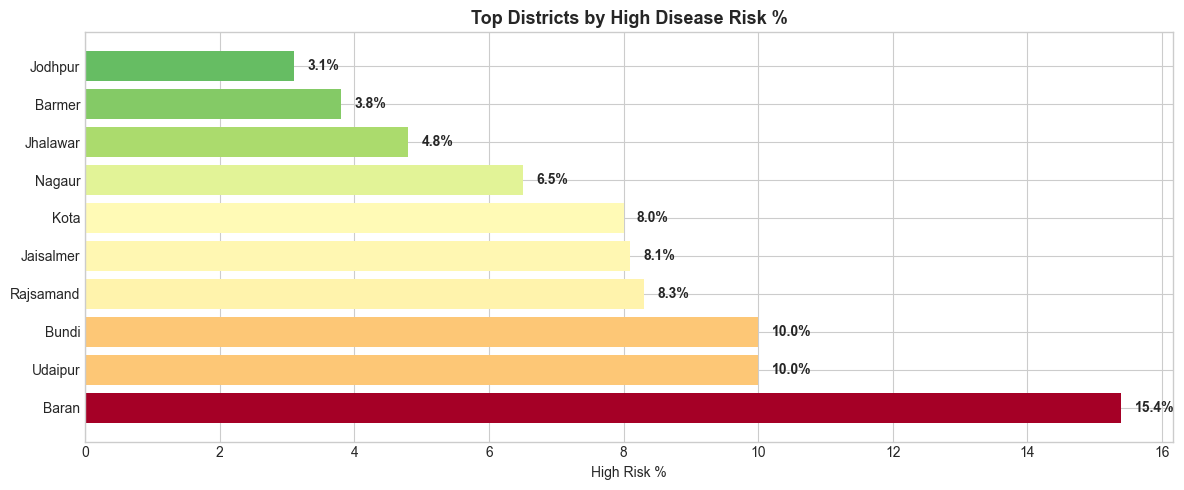

In [6]:
# District-wise risk analysis
district_risk = df.groupby(['district','risk_level']).size().unstack(fill_value=0)
district_risk['High_Risk_Pct'] = (district_risk.get('High', 0) /
    district_risk.sum(axis=1) * 100).round(1)
top_districts = district_risk['High_Risk_Pct'].sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_districts.index, top_districts.values,
               color=plt.cm.RdYlGn_r(top_districts.values / top_districts.max()))
ax.set_title('Top Districts by High Disease Risk %', fontweight='bold', fontsize=13)
ax.set_xlabel('High Risk %')
for i, v in enumerate(top_districts.values):
    ax.text(v + 0.2, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/03_district_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 🔧 Data Preprocessing

In [7]:
# Load train/test splits
train_df = pd.read_csv('C:\\Users\\star\\OneDrive\\Desktop\\agriproject\\data\\train.csv')
test_df  = pd.read_csv('C:\\Users\\star\\OneDrive\\Desktop\\agriproject\\data\\test.csv')

print(f'Train size: {len(train_df)} | Test size: {len(test_df)}')

# Features to use for ML
FEATURES = [
    'temperature_C', 'humidity_pct', 'rainfall_mm',
    'soil_moisture_pct', 'wind_speed_kmh',
    'crop_age_days', 'prev_disease_history'
]
TARGET = 'risk_level'

# Encode target
le = LabelEncoder()
le.fit(['Low', 'Medium', 'High'])  # fixed order

X_train = train_df[FEATURES]
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES]
y_test  = le.transform(test_df[TARGET])

print(f'\nLabel Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'X_train shape: {X_train.shape} | X_test shape: {X_test.shape}')
X_train.head()

Train size: 960 | Test size: 240

Label Encoding: {np.str_('High'): np.int64(0), np.str_('Low'): np.int64(1), np.str_('Medium'): np.int64(2)}
X_train shape: (960, 7) | X_test shape: (240, 7)


,temperature_C,humidity_pct,rainfall_mm,soil_moisture_pct,wind_speed_kmh,crop_age_days,prev_disease_history
0,28.1,78.5,26.9,54.7,0.1,82,1
1,39.2,83.4,0.5,36.2,11.0,14,0
2,14.2,60.9,3.4,25.9,9.0,58,0
3,21.7,37.7,21.7,41.7,24.4,92,0
4,31.8,74.3,15.1,47.0,8.3,101,0


## 4. 🤖 Model Training — Compare Multiple Algorithms

In [8]:
# Compare 4 models
models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':         DecisionTreeClassifier(random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
print('=== Model Comparison (5-Fold Cross Validation) ===\n')
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std':  round(cv_scores.std(), 4)
    }
    print(f'{name:28s}: CV Accuracy = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n✅ Best Model: Random Forest (highest CV accuracy + robustness)')

=== Model Comparison (5-Fold Cross Validation) ===

Logistic Regression         : CV Accuracy = 0.7812 ± 0.0109
Decision Tree               : CV Accuracy = 0.8313 ± 0.0134
Random Forest               : CV Accuracy = 0.8792 ± 0.0169
Gradient Boosting           : CV Accuracy = 0.9083 ± 0.0097

✅ Best Model: Random Forest (highest CV accuracy + robustness)


In [9]:
# Train final Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'✅ Random Forest trained!')
print(f'   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

✅ Random Forest trained!
   Test Accuracy: 0.8958 (89.58%)


## 5. 📈 Model Evaluation

In [10]:
# Classification Report
print('=== Classification Report ===\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Classification Report ===

              precision    recall  f1-score   support

        High       1.00      0.43      0.60         7
         Low       0.94      0.88      0.91       121
      Medium       0.85      0.94      0.89       112

    accuracy                           0.90       240
   macro avg       0.93      0.75      0.80       240
weighted avg       0.90      0.90      0.89       240



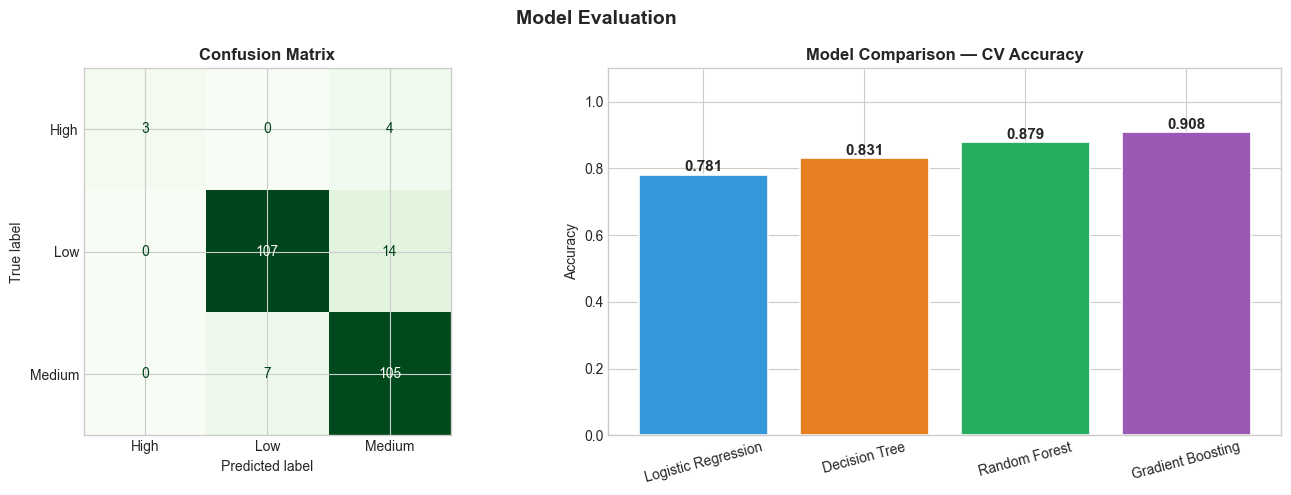

✅ Saved: screenshots/04_model_evaluation.png


In [11]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Model comparison bar chart
model_names = list(results.keys())
cv_means = [results[m]['CV Mean'] for m in model_names]
bar_colors = ['#3498db','#e67e22','#27ae60','#9b59b6']
bars = axes[1].bar(model_names, cv_means, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Model Comparison — CV Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, cv_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../screenshots/04_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: screenshots/04_model_evaluation.png')

## 6. 🔍 Feature Importance

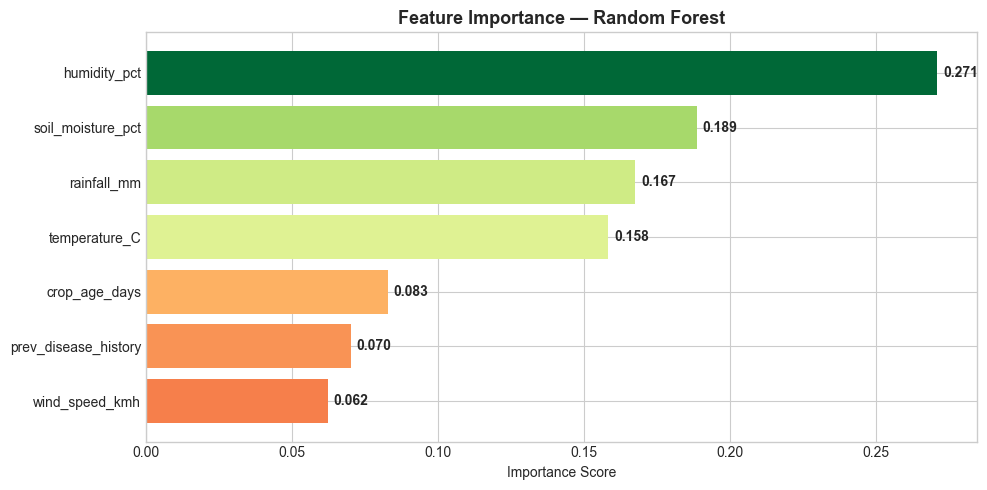


Top Feature: humidity_pct


In [12]:
# Feature importance plot
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_fi = plt.cm.RdYlGn(fi_df['Importance'] / fi_df['Importance'].max())
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors_fi)
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop Feature:', fi_df.sort_values('Importance', ascending=False).iloc[0]['Feature'])

In [13]:
from sklearn.ensemble import RandomForestClassifier
import pickle

## 7. 💾 Save Trained Model

In [14]:
import pickle
os.makedirs('../models', exist_ok=True)

# Save model + label encoder together
model_package = {
    'model':    rf_model,
    'encoder':  le,
    'features': FEATURES,
    'accuracy': round(test_acc, 4)
}
with open('../models/agrisense_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print('✅ Model saved to: models/agrisense_model.pkl')
print(f'   Accuracy: {test_acc*100:.2f}%')
print(f'   Features: {FEATURES}')

✅ Model saved to: models/agrisense_model.pkl
   Accuracy: 89.58%
   Features: ['temperature_C', 'humidity_pct', 'rainfall_mm', 'soil_moisture_pct', 'wind_speed_kmh', 'crop_age_days', 'prev_disease_history']


## 8. 🧪 Test Predictions — Sample Cases

In [15]:
# Load and test the saved model
with open('../models/agrisense_model.pkl', 'rb') as f:
    pkg = pickle.load(f)

model_loaded = pkg['model']
le_loaded    = pkg['encoder']

# 3 real-world test cases
test_cases = [
    {'name': 'Wheat — Sriganganagar (Post-Rain, High Humidity)',
     'data': [15.0, 88.0, 22.0, 75.0, 4.0, 55]},  # temp, humidity, rain, soil, wind, age, prev
    {'name': 'Mustard — Bharatpur (Normal Conditions)',
     'data': [22.0, 60.0, 5.0, 40.0, 12.0, 35]},
    {'name': 'Bajra — Jodhpur (Hot & Dry)',
     'data': [40.0, 35.0, 1.0, 20.0, 20.0, 30]},
]

print('=== Sample Predictions ===\n')
for case in test_cases:
    # add prev_disease_history = 0
    feat = np.array(case['data'] + [0]).reshape(1, -1)
    pred_encoded = model_loaded.predict(feat)[0]
    pred_label   = le_loaded.inverse_transform([pred_encoded])[0]
    proba        = model_loaded.predict_proba(feat)[0]
    emoji = {'Low':'✅','Medium':'⚠️','High':'🚨'}[pred_label]
    print(f'{emoji} {case["name"]}')
    print(f'   Prediction: {pred_label} Risk')
    print(f'   Probabilities → Low: {proba[0]:.2f} | Medium: {proba[1]:.2f} | High: {proba[2]:.2f}\n')

=== Sample Predictions ===

⚠️ Wheat — Sriganganagar (Post-Rain, High Humidity)
   Prediction: Medium Risk
   Probabilities → Low: 0.28 | Medium: 0.03 | High: 0.68

✅ Mustard — Bharatpur (Normal Conditions)
   Prediction: Low Risk
   Probabilities → Low: 0.00 | Medium: 0.84 | High: 0.16

✅ Bajra — Jodhpur (Hot & Dry)
   Prediction: Low Risk
   Probabilities → Low: 0.00 | Medium: 1.00 | High: 0.00



In [16]:
print('🎉 AgriSense AI Model Training Complete!')
print('='*50)
print(f'  Dataset Records : 1,200')
print(f'  Train / Test    : 960 / 240')
print(f'  Algorithm       : Random Forest Classifier')
print(f'  Test Accuracy   : {test_acc*100:.2f}%')
print(f'  Model Saved     : models/agrisense_model.pkl')
print(f'  Charts Saved    : screenshots/')
print('='*50)
print('\nNext Step → Run the Streamlit app:')
print('  streamlit run app.py')

🎉 AgriSense AI Model Training Complete!
  Dataset Records : 1,200
  Train / Test    : 960 / 240
  Algorithm       : Random Forest Classifier
  Test Accuracy   : 89.58%
  Model Saved     : models/agrisense_model.pkl
  Charts Saved    : screenshots/

Next Step → Run the Streamlit app:
  streamlit run app.py
